# Notebook Objectives

This notebook computes neural values for one session. For all sessions, we do the same in ```neural_value_RUN_all_sessions.py```, results shown in ```neural_value_all_sessions.ipynb```.

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)
* Change in neural value, etc

---
# Setup


In [6]:
from helpers import *
from popy.config import COLORS

In [7]:
##% data loading
def load_mega_custom(monkey=None, area=None, subregion=None, downsample=True):
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_history')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    if area is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.area == area)
    if subregion is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion == subregion)

    if monkey is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.monkey == monkey)

    # use only time points of every .1 s
    if downsample:
        time_vector = neural_dataset.time.values
        time_vector = np.unique(np.round(time_vector, 1))  # round to 1 decimal place to avoid floating point issues
        neural_dataset = neural_dataset.sel(time=time_vector, method='nearest')

    # add coordinates (should be added during the dataset creation)
    neural_dataset = neural_dataset.assign_coords(R_1=('trial_id', [0 if hist in [0, 1, 2, 3] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_2=('trial_id', [0 if hist in [0, 1, 4, 5] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_3=('trial_id', [0 if hist in [0, 2, 4, 6] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(fb_sequence=('trial_id', neural_dataset.history_of_feedback.values))
    neural_dataset = neural_dataset.assign_coords(fb_sequence_m1=('trial_id', neural_dataset.history_of_feedback.values%4))
    neural_dataset = neural_dataset.assign_coords(time_m1=('time', neural_dataset.time.values + 7.5))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data
    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

---
# Section 1: Get data, extract neural value

In [8]:
monkey, session, subregion = 'ka', '030522', 'MCC'

t_interest_value = [1, 3.5]  # seconds
build_data = True

all_figs = []

In [9]:
#neural_dataset = load_mega_custom(monkey='ka', subregion='MCC')

In [10]:
floc = 'temp/{}_{}_neural.nc'.format(monkey, session)

if not build_data: 
    neural_dataset_all = xr.open_dataset(floc)
else:
    neural_dataset_all = load_data_custom(monkey, session, n_extra_trials=(-1, 1), sr=10)
    # save the dataset
    neural_dataset_all.to_netcdf(floc)

neural_dataset = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 6, trial_id: 376, time: 225)
Coordinates: (12/25)
  * unit              (unit) object 'MCC_02_01' 'MCC_06_02' ... 'MCC_15_01'
    unit_id_original  (unit) int64 8 85 111 37 46 56
    channel           (unit) int64 2 6 10 11 13 15
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '030522' '030522' ... '030522' '030522'
    area              (unit) object 'MCC' 'MCC' 'MCC' 'MCC' 'MCC' 'MCC'
    ...                ...
    R_3               (trial_id) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 1.0 1.0 1.0
    R_4               (trial_id) float64 0.0 0.0 0.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    R_5               (trial_id) float64 1.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 0.0 1.0
    R_6               (trial_id) float64 1.0 1.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 0.0
    R_7               (trial_id) float64 0.0 1.0 1.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
    R_8               (trial_id) float64 1.0 0.0 1.0 1.0 0.0 ... 0.0 1.0 1.0 1.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.4301 -0.4301 ... -0.455
Attributes:
    bin_size:  0.1

In [11]:
neural_dataset.coords

Coordinates:
  * unit              (unit) object 'MCC_02_01' 'MCC_06_02' ... 'MCC_15_01'
    unit_id_original  (unit) int64 8 85 111 37 46 56
    channel           (unit) int64 2 6 10 11 13 15
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '030522' '030522' ... '030522' '030522'
    area              (unit) object 'MCC' 'MCC' 'MCC' 'MCC' 'MCC' 'MCC'
    subregion         (unit) object 'MCC' 'MCC' 'MCC' 'MCC' 'MCC' 'MCC'
  * trial_id          (trial_id) int64 8 9 10 11 12 13 ... 418 419 420 421 422
  * time              (time) float64 -7.5 -7.4 -7.3 -7.2 ... 14.6 14.7 14.8 14.9
    epoch             (time) float64 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0 5.0
    block_id          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9
    best_target       (trial_id) int64 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    target            (trial_id) float64 1.0 3.0 2.0 2.0 2.0 ... 1.0 1.0 1.0 1.0
    feedback          (trial_id) floa

In [12]:
# binarize neural value to 8 levels from 0 to 1
neural_value = neural_dataset.stay_value.values
neural_value_binary = np.digitize(neural_value, bins=np.linspace(0, 1, 9)) - 1
neural_value_binary = neural_value_binary.astype(np.float32)
# add new coordinate
neural_dataset = neural_dataset.assign_coords(fb_sequence_original=('trial_id', neural_dataset.fb_sequence.values))
# store original fb_sequence data
neural_dataset.fb_sequence.data = neural_value_binary
neural_dataset

AttributeError: 'Dataset' object has no attribute 'fb_sequence'

## Projection to value subspace

In [ ]:
#results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
data_projected = time_resolved_decoder_all_time(neural_dataset, target='fb_sequence')

# get neural value for the current trial and the previous one
data_projected = add_neural_value_coord(data_projected, t_interest=t_interest_value)

In [ ]:
data_projected

<xarray.DataArray (trial_id: 386, time: 225)>
array([[-0.29271185, -0.31515724, -0.60536796, ...,  0.15103762,
         0.55674148, -0.24820291],
       [-0.76574131, -0.47604219, -0.39170715, ..., -0.16821722,
        -0.46595838, -0.87903472],
       [-0.66882476, -0.48351723, -0.20136654, ...,  0.40111002,
        -0.80682674, -1.10872012],
       ...,
       [ 1.22161155,  0.46429612,  0.06338321, ..., -0.01007605,
         0.39976256, -0.6025704 ],
       [ 0.06259638,  0.56599868,  0.15157714, ..., -0.08853685,
         1.10197334,  0.66213629],
       [-0.03015595, -0.50478904, -0.42222445, ..., -0.05998823,
        -0.34276719,  0.25521871]])
Coordinates: (12/28)
  * trial_id              (trial_id) int64 8 9 10 11 12 ... 416 417 418 419 423
    block_id              (trial_id) int64 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9
    best_target           (trial_id) int64 1 1 1 1 1 1 1 1 1 ... 3 3 3 3 3 3 3 3
    target                (trial_id) float64 3.0 1.0 1.0 1.0 ... 3.0 3.0 3.0 3.0
    feedback              (trial_id) float64 0.0 1.0 1.0 1.0 ... 0.0 1.0 1.0 0.0
    switch                (trial_id) float64 1.0 1.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...                    ...
    V_t                   (trial_id) float64 0.03509 -0.1183 ... 0.0158 -0.359
    V_t_p1                (trial_id) float64 -0.1183 0.2396 0.2933 ... nan nan
    dV                    (trial_id) float64 -0.1534 0.3579 0.05373 ... nan nan
    V_t_behav             (trial_id) float64 0.1573 0.06166 ... 0.6917 0.2833
    V_t_p1_behav          (trial_id) float64 0.06166 0.5016 0.7209 ... nan nan
    dV_behav              (trial_id) float64 -0.09567 0.44 0.2193 ... nan nan

In [ ]:
# save data_projected
#data_projected.to_netcdf('data/{}_{}_data_proj.nc'.format(monkey, session))

# load data_projected
#data_projected = xr.open_dataset('data/{}_{}_data_proj.nc'.format(monkey, session))

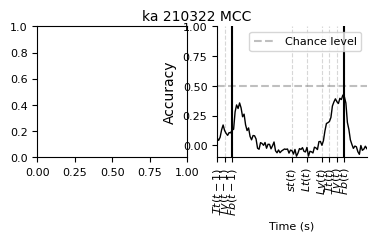

In [ ]:
# Plot the results
fig, axes = plot_across_time_decodability(projected_data=data_projected, vmin=-.1, vmax=1)

plt.suptitle('{} {} {}'.format(monkey, session, subregion), fontsize=10)

# Save the figure
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_across_time_decodability.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

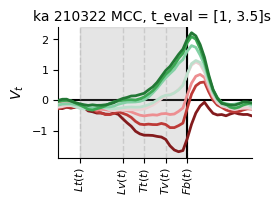

In [ ]:
fig, ax = plot_projected_data(data_projected, t_interest_value=t_interest_value, n_extra_trials=(-1, 0), xlim=[0.5, 5], paper_format=True)
# hide legend
plt.suptitle(f'{monkey} {session} {subregion}, t_eval = {t_interest_value}s', fontsize=10)

# save figure
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_projection.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

In [ ]:
from matplotlib.lines import Line2D

def plot_projected_data_switch(data_projected, t_interest_value=None, normalize=False, n_extra_trials=(0, 1), xlim=None, paper_format=False, ax=None):
    # project to axis
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h = 2  # in cm
        w = 2.5
        linewidth = 2
    else:
        plt.rcParams.update({'font.size': 12})
        h = 6  # in cm
        w = 8  # in cm
        linewidth = 1.5

    r1s = [0, 1]
    r2s = [0, 1]
    target1s = [0, 1]  # 0: no switch, 1: switch

    colors = value_gradient(4)
    linestyles = {1: '-', 0: '--'}
    target_labels = {1: 'target 1', 0: 'target 2 or 3'}
    hist_labels = {(0, 0): '$R_{t-1}=0, R_t=0$', (0, 1): '$R_{t-1}=1, R_t=0$', (1, 0): '$R_{t-1}=0, R_t=1$', (1, 1): '$R_{t-1}=1, R_t=1$'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(w, h))

    # 500 ms for convolution
    dt = data_projected.time.values[1] - data_projected.time.values[0]
    n_convolution_bins = int(1 / dt)
    window = np.ones(n_convolution_bins) / n_convolution_bins

    time_vector = data_projected.time.values

    # bwr colormap, n=8 sampples RdYlGn
        
    for i_s, target1 in enumerate(target1s):
        for i_past, (r1, r2) in enumerate(itertools.product(r1s, r2s)):
            data_temp = data_projected.sel(
                trial_id=(data_projected.target_1 == target1) & (data_projected.feedback == r1) & (data_projected.R_1 == r2)
                )

            class_mean = data_temp.mean(dim='trial_id').values
            class_mean_smoothed = ndimage.convolve(class_mean, window, mode='nearest')

            ax.plot(time_vector, class_mean_smoothed, color=colors[i_past], label=f'{target_labels[target1]}, \t\t{hist_labels[(r1, r2)]}', linewidth=linewidth, zorder=10, linestyle=linestyles[target1])

    if t_interest_value is not None:
        ax.axvspan(t_interest_value[0], t_interest_value[1], color='grey', alpha=0.2, label='eval window')

    # add behav keyboints
    plot_keypoints(ax, n_extra_trials, mark_event='Fb', xlabels='events')
    # y grid only
    ax.grid(axis='x', alpha=.5, linewidth=1, linestyle='--')
    ax.axhline(0, color='k', linestyle='-', linewidth=linewidth*.75, zorder=0)

    # remove left and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Apply the custom legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    # move legend outside
    if not paper_format:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # save as svg
    ax.set_ylabel('$V_t$', fontsize=10)
    '''if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('Neural value')'''
    
    if xlim is not None:    
        ax.set_xlim(xlim)

    return fig, ax

# plot_projected_data_switch(data_projected, t_interest_value=None, n_extra_trials=(-1, 1), paper_format=False)

## Extract neural value

In [13]:
behav_new = data_projected.mean('time').coords.to_dataset().to_dataframe().reset_index()

behav_new['monkey'] = monkey
behav_new['session'] = session
#behav_new['area'] = neural_dataset.area
behav_new['subregion'] = subregion

# put monkey, session, subregion in the front
behav_new = behav_new[['monkey', 'session', 'subregion'] +
                       [c for c in behav_new.columns if c not in ['monkey', 'session', 'subregion']]]
behav_new = behav_new.dropna()
behav_new


NameError: name 'data_projected' is not defined

In [ ]:
# save behav_new to csv
#behav_new.to_csv(f'data/{monkey}_{session}_{subregion}_neural_value.csv', index=False)

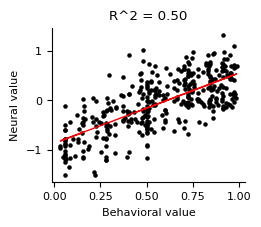

In [ ]:
# plot neural value against behavioral value
neural_value = behav_new.V_t.values
behavioral_value = behav_new.V_t_behav.values

fig, ax = plt.subplots(figsize=(2.5, 2))
ax.scatter(behavioral_value, neural_value, color='k', s=5)
# fit linear regression
from sklearn.linear_model import LinearRegression
X = behavioral_value.reshape(-1, 1)
y = neural_value
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
ax.plot(X, y_pred, color='r', linewidth=1)
# get R^2
r2 = reg.score(X, y)
ax.set_xlabel('Behavioral value')
ax.set_ylabel('Neural value')
ax.set_title(f'R^2 = {r2:.2f}')

sns.despine()
# save figure

---
# Section 2: Analysis of the neural value representation

## Green red plot: Value evolves according to feedback

Spearman correlation (rho): 0.673, p-value: 7.3e-51
Spearman correlation positive sequences (rho): 0.388, p-value: 4.8e-10
Spearman correlation negative sequences (rho): 0.573, p-value: 2.9e-13


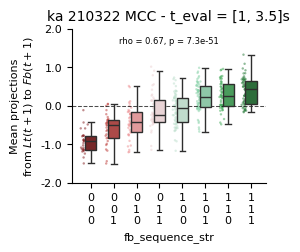

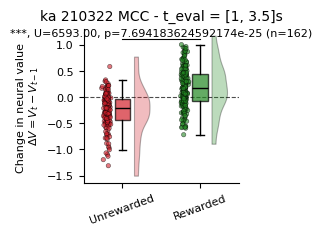

In [ ]:
'''fig, ax = plot_projection_timepoint(behav_new, paper_format=True, ylim=None, show_datapoints=True)

plt.suptitle(f'{monkey} {session} {subregion}, t_fit = {t_interest_value} s', fontsize=10)

all_figs.append(fig)
'''

fig, ax = plot_Vt_per_sequence(behav_new, paper_format=True, ylim=None, show_datapoints=True, showfliers=False)
ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_Vt_per_sequence.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

fig, ax = create_r_style_plot(None, behav_new, 'feedback', 'dV', paper_format=True)
ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_feedback_dV.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

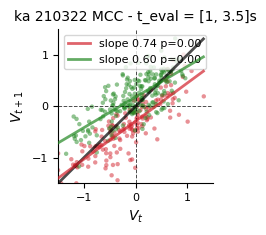

In [ ]:
fig, ax = green_red_plot(behav_new, paper_format=True)
#plt.suptitle(f'{monkey} {session} {subregion}, t_fit = {t_interest_value} s', fontsize=10)

ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)

#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_green_red.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

In [ ]:
n_perms = 100

cpds_all = process_single_session(behav_new)
#cpds_all = add_corrected_pvals(pd.DataFrame([cpds_all]))
cpds_all = pd.DataFrame([cpds_all])
cpds_all

,cpd_R_1,pval_R_1,cpd_R_2,pval_R_2,cpd_R_3,pval_R_3,cpd_R_4,pval_R_4,cpd_R_5,pval_R_5,cpd_R_6,pval_R_6,cpd_R_7,pval_R_7,cpd_R_8,pval_R_8,monkey,session,subregion
0,47.340862,0.009901,22.793486,0.009901,10.787898,0.009901,6.826961,0.009901,3.962523,0.009901,1.678022,0.009901,0.020172,0.712871,0.153835,0.425743,ka,210322,MCC


In [ ]:
def plot_cpds_history_neural_value(cpd_temp, null=None, ax=None, show_data=False, ylim=None):
    axis_original = ax
    if ax is None:
        h = 1.5  # in cm
        w = 1.5
        s = 10
        linewidth = 0.7
        fig, ax = plt.subplots(1, 1, figsize=(w, h))

    monkey, subregion = cpd_temp.monkey.unique()[0], cpd_temp.subregion.unique()[0]

    cpd_cols = [col for col in cpd_temp.columns if col.startswith('cpd_R_')]
    ymax = cpd_temp.groupby(['monkey', 'subregion'])[cpd_cols].mean().max().max()

    cpd_vals = cpd_temp[cpd_cols]
    cpd_means = cpd_vals.mean().values
    cpd_sems = cpd_vals.std().values

    # Determine significance for each point
    significance = []
    for i, reg in enumerate(cpd_cols):
        if null is None:
            pcol = f'pval_{"_".join(reg.split("_")[1:])}'
            pval = cpd_temp[pcol].values[0]
        else:
            pval = np.sum(null >= cpd_means[i]) / null.shape[0]
        significance.append(pval < 0.05)

    # Plot error bars (without markers)
    ax.errorbar(range(1, len(cpd_means)+1), cpd_means, yerr=cpd_sems, 
           fmt='-', color=COLORS[subregion], 
           label='session mean ± SEM', 
           capsize=2, zorder=1)
    
    # Plot markers separately based on significance
    for i, (mean, sig) in enumerate(zip(cpd_means, significance)):
        fillstyle = 'full' if sig else 'none'
        ax.plot(i+1, mean, 'o', 
                color=COLORS[subregion], 
                markeredgecolor='black', 
                markeredgewidth=0.5,
                fillstyle=fillstyle,
                markersize=6, 
                zorder=2)
    
    # Plot individual sessions
    if show_data:
        for i, col in enumerate(cpd_vals.columns):
            xpos = i+1 - 0.3
            jitter = np.random.normal(0, 0.05, size=len(cpd_vals[col]))
            ax.scatter(xpos + jitter, cpd_vals[col].values, color='black', alpha=0.2, zorder=0, s=2)

    ax.axhline(0, color='black', linestyle='dotted', alpha=0.3)
    ax.set_title(f'{monkey} {subregion}')
    ax.set_ylabel('CPD (%)')
    ax.set_xticks(range(1, len(cpd_cols)+1))
    ax.set_xticklabels([f't-{i}' for i in range(1, len(cpd_cols)+1)], rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ylim is not None:
        ax.set_ylim(ylim)

    if axis_original is None:
        return fig, ax
    return ax

saved figure at figs/neural_value/single_sessions/ka_210322_MCC_cpds.svg


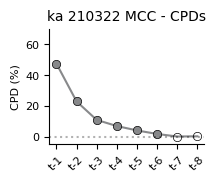

In [ ]:
#null = create_permutation_null(behav_new, n_perms=100)

fig, axs = plt.subplots(1, 1, figsize=(2, 1.5))
axs = plot_cpds_history_neural_value(cpds_all, ax=axs, ylim=[-5, 70])

# remove title from axes
axs.set_title(f'{monkey} {session} {subregion} - CPDs', fontsize=10)

#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_cpds.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)
print("saved figure at figs/neural_value/single_sessions/{}_{}_{}_cpds.svg".format(monkey, session, subregion))

---
# Save figs